In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
path = '/kaggle/input/pathogen-dataset/pathogen'

# Data Handling


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 30

In [6]:
#  a list of all image filepaths and their corresponding labels.
filepaths = []
labels = []

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        filepaths.append(os.path.join(dirname, filename))
        labels.append(os.path.basename(dirname))

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print("DataFrame created successfully. First 5 rows:")
print(df.head())

DataFrame created successfully. First 5 rows:
Empty DataFrame
Columns: [filepath, label]
Index: []


In [10]:
# Splitting the Data
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

num_classes = len(df['label'].unique())
print(f"Number of classes found: {num_classes}")

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [11]:
train_datagen = ImageDataGenerator(
preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NameError: name 'train_df' is not defined

In [1]:
train_datagen.class_indices

NameError: name 'train_datagen' is not defined

# BUILD THE MODEL

In [7]:
# Load the base MobileNetV2 model, pre-trained on ImageNet
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model to use it as a feature extractor
base_model.trainable = False

# Create our custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
num_classes = num_classes
outputs = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1762260996.871627      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762260996.872334      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# TRAINING MODEL

In [8]:
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
    mode='max'
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.000001, 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [9]:
print("\nStarting Initial Training (Frozen Base Model)")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[model_checkpoint, early_stopping]
)


Starting Initial Training (Frozen Base Model)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1762261009.115896      62 service.cc:148] XLA service 0x7e3838110360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762261009.117331      62 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762261009.117353      62 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762261010.112347      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/1000 ━━━━━━━━━━━━━━━━━━━━ 3:52:41 14s/step - accuracy: 0.3438 - loss: 2.0491

I0000 00:00:1762261015.388780      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.5509 - loss: 1.1968
Epoch 1: val_accuracy improved from -inf to 0.89075, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 721s 708ms/step - accuracy: 0.5511 - loss: 1.1964 - val_accuracy: 0.8907 - val_loss: 0.3898
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8596 - loss: 0.4404
Epoch 2: val_accuracy improved from 0.89075 to 0.92200, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 448s 448ms/step - accuracy: 0.8596 - loss: 0.4404 - val_accuracy: 0.9220 - val_loss: 0.2689
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8990 - loss: 0.3195
Epoch 3: val_accuracy improved from 0.92200 to 0.93250, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 448s 448ms/step - accuracy: 0.8991 - loss: 0.3195 - val_accuracy: 0.9325 - val_loss: 0.2280
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9113 - loss: 0.2744
Epoch 4: val_accur

# FINE-TUNING

In [10]:
print("\n--- Starting Fine-Tuning Phase ---")

base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 100),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    initial_epoch=history.epoch[-1],
    callbacks=[model_checkpoint, early_stopping, lr_scheduler]
)


--- Starting Fine-Tuning Phase ---
Epoch 26/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.6699 - loss: 1.1385
Epoch 26: val_accuracy did not improve from 0.95425
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 467s 442ms/step - accuracy: 0.6700 - loss: 1.1382 - val_accuracy: 0.9325 - val_loss: 0.2036 - learning_rate: 1.0000e-06
Epoch 27/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8626 - loss: 0.3976
Epoch 27: val_accuracy did not improve from 0.95425
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 435s 435ms/step - accuracy: 0.8626 - loss: 0.3976 - val_accuracy: 0.9388 - val_loss: 0.1824 - learning_rate: 1.0000e-06
Epoch 28/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8998 - loss: 0.2961
Epoch 28: val_accuracy did not improve from 0.95425
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 427s 427ms/step - accuracy: 0.8998 - loss: 0.2961 - val_accuracy: 0.9463 - val_loss: 0.1628 - learning_rate: 1.0000e-06
Epoch 29/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9118 - loss

# FINAL EVALUATION


--- Preparing Final Analysis ---

--- Plotting Combined Learning Curves ---


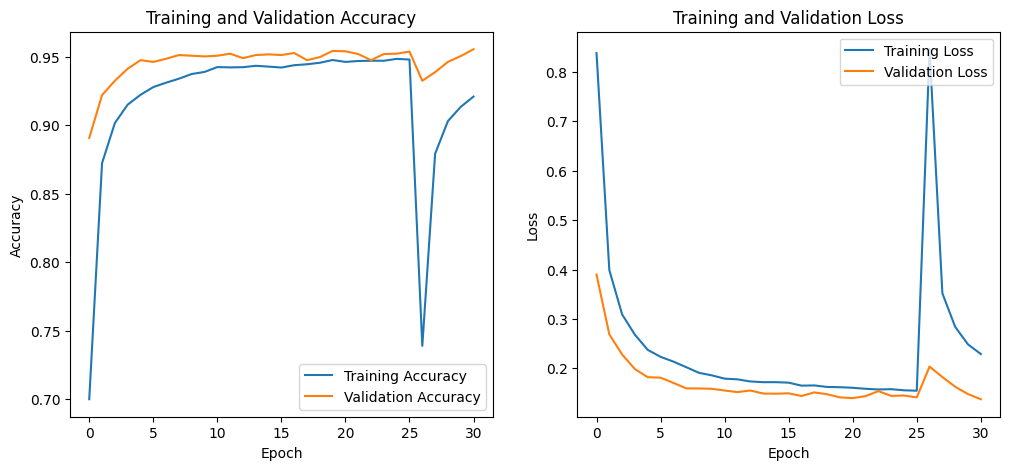


--- Loading the best performing model from 'best_model.keras' ---

--- Evaluating the BEST Performing Model on the Test Set ---
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 351ms/step - accuracy: 0.9545 - loss: 0.1486
Final Test Accuracy: 95.25%


In [11]:
print("\n--- Preparing Final Analysis ---")

if 'history' in locals() and 'history_fine' in locals():
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']
else:
    acc = history_fine.history['accuracy']
    val_acc = history_fine.history['val_accuracy']
    loss = history_fine.history['loss']
    val_loss = history_fine.history['val_loss']
    
if val_acc and val_loss:
    print("\n--- Plotting Combined Learning Curves ---")
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig('/kaggle/working/Learning_Curve_plot.png')
    plt.show()                                                  

print("\n--- Loading the best performing model from 'best_model.keras' ---")
best_model = tf.keras.models.load_model('best_model.keras')

print("\n--- Evaluating the BEST Performing Model on the Test Set ---")
loss, accuracy = best_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

In [12]:
print("\nExporting the Best Model")

# 1. Export to Keras SavedModel Format
best_model.save('pathogen_model.keras')
print("Successfully exported to Keras SavedModel format: 'pathogen_model_keras'")

print("\nExporting to TFLite Format")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] 
tflite_model = converter.convert()

# Save the TFLite model file
with open('pathogen_model_final.tflite', 'wb') as f:
    f.write(tflite_model)
print("Successfully exported TFLite model: 'pathogen_model_final.tflite'")

# Export Class Names
class_names = list(train_generator.class_indices.keys())
with open('pathogen_labels_final.txt', 'w') as f:
    f.write('\n'.join(class_names))
print("Successfully exported labels: 'pathogen_labels_final.txt'")


Exporting the Best Model
Successfully exported to Keras SavedModel format: 'pathogen_model_keras'

Exporting to TFLite Format
Saved artifact at '/tmp/tmpow3n0sd7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138780765335248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765336400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765336784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765336592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765335440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765336016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765338512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765339280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780765338704: TensorSpec(

W0000 00:00:1762275036.377160      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762275036.377200      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1762275036.517077      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


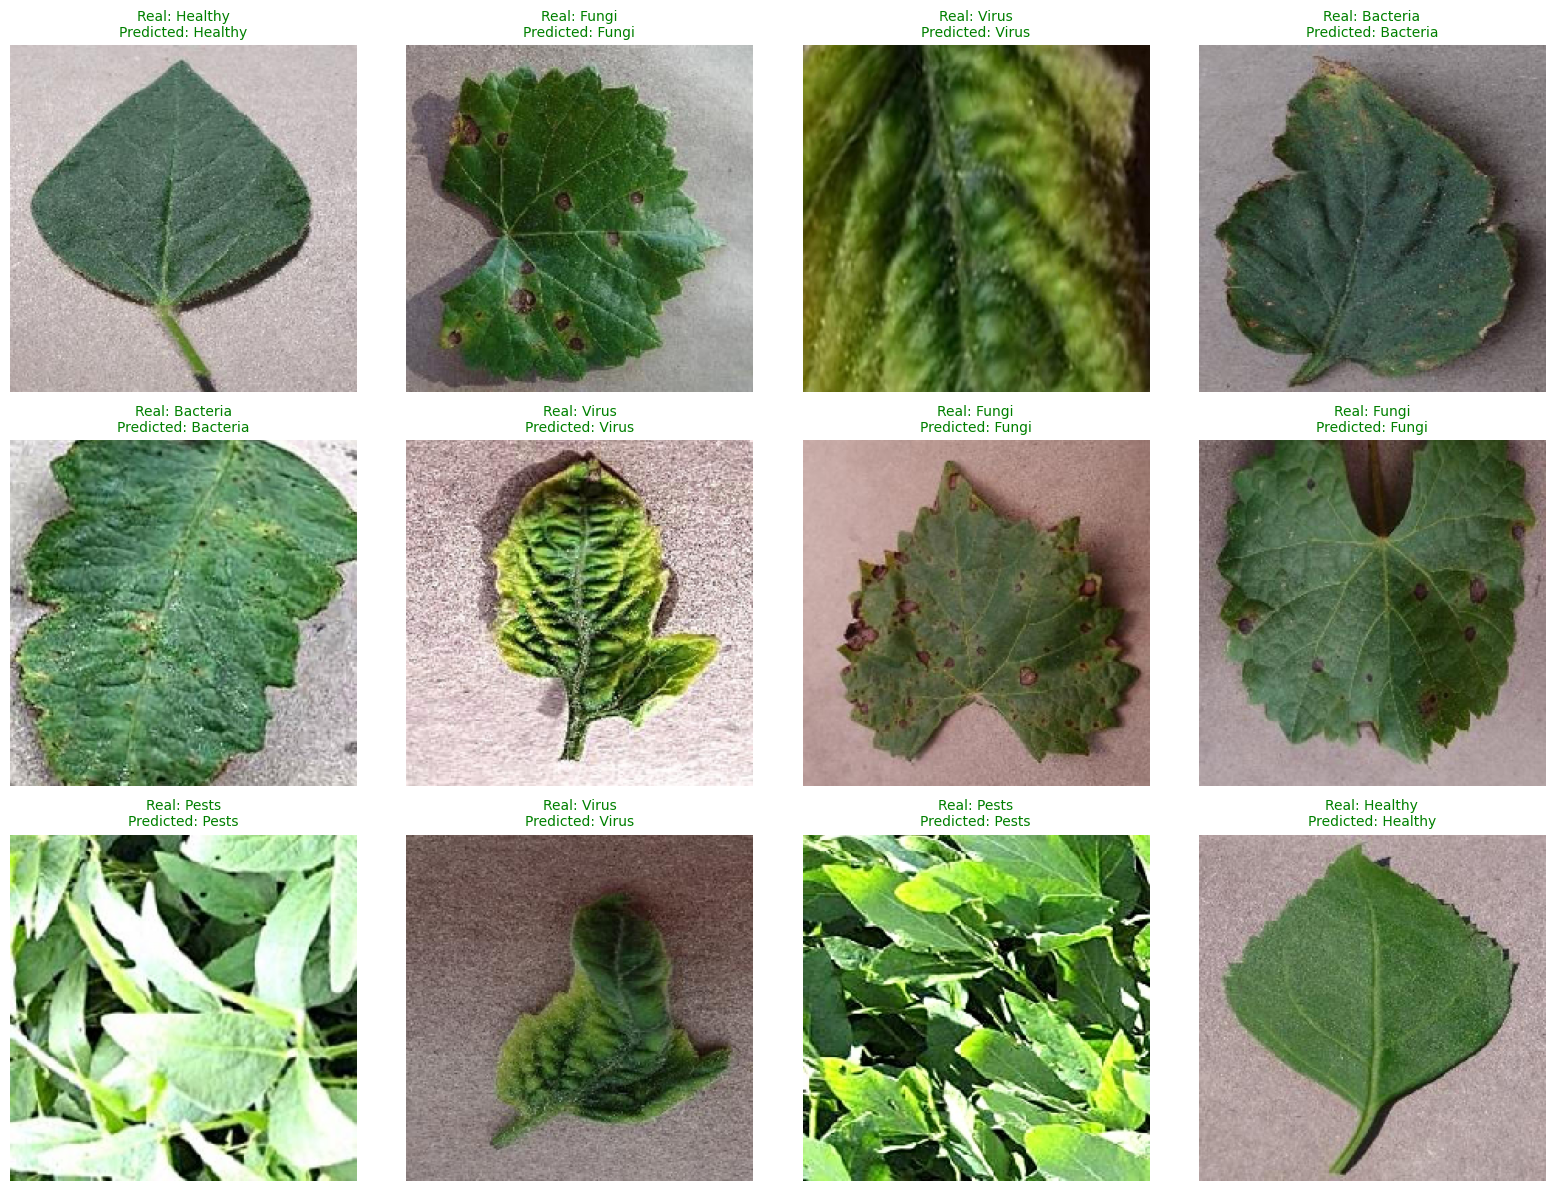

In [13]:
batch = next(test_generator)
images, labels = batch

predictions = best_model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

class_names_list = list(class_names)

def deprocess_image(img):
    return (img + 1) / 2.0

plt.figure(figsize=(16, 12))
for i in range(12):
    if i >= len(images): 
        break
    plt.subplot(3, 4, i + 1)
    plt.imshow(deprocess_image(images[i]))
    
    real_label = class_names_list[np.argmax(labels[i])]
    predicted_label = class_names_list[predicted_labels[i]]
    
    title_color = 'green' if real_label == predicted_label else 'red'
    
    plt.title(f'Real: {real_label}\nPredicted: {predicted_label}', fontsize=10, color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/Batch_Predection_plot.png')
plt.show()

In [14]:
print("Preparing to test the model")

MODEL_PATH = '/kaggle/working/pathogen_model_final.tflite'
LABELS_PATH = '/kaggle/working/pathogen_labels_final.txt'
TEST_IMAGE_PATH = '/kaggle/input/pathogen123/fungi.jpeg'

# Load the Model and Labels
with open(LABELS_PATH, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
print(f"Loaded {len(class_names)} class labels.")

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
_, height, width, _ = input_details[0]['shape']

print(f"Model expects input shape: ({height}, {width})")

img = image.load_img(TEST_IMAGE_PATH, target_size=(height, width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

preprocessed_img = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Make a Prediction
interpreter.set_tensor(input_details[0]['index'], preprocessed_img)
interpreter.invoke()
predictions = interpreter.get_tensor(output_details[0]['index'])

# Interpret and Display the Result
predicted_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_index]
confidence_score = np.max(predictions[0])

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name}\\nConfidence: {confidence_score*100:.2f}%")
plt.axis("off")
plt.savefig('/kaggle/working/Model_Test.png')
plt.show()

print("\nPrediction complete.")

Preparing to test the model
Loaded 5 class labels.
Model expects input shape: (224, 224)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


NameError: name 'image' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

MODEL_PATH = '/kaggle/working/pathogen_model_keras'
LABELS_PATH = '/kaggle/input/pathogen-identifier/tflite/default/1/pathogen_labels_final.txt'
TEST_IMAGE_PATH = '/kaggle/input/pathogen123/Bacteria leaf.jpg'
IMG_SIZE = 512

try:
    # 1. Load the Model and Labels
    print(f"Loading model from: {MODEL_PATH}...")
    model = tf.keras.models.load_model(MODEL_PATH)

    with open(LABELS_PATH, 'r') as f:
        class_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(class_names)} class labels.")

    # 2. Load and Preprocess the Test Image
    print(f"\nProcessing image: {TEST_IMAGE_PATH}...")
    
    # Load and resize the image
    img = image.load_img(TEST_IMAGE_PATH, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    
    # Add a batch dimension: (512, 512, 3) -> (1, 512, 512, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Apply MobileNetV2 Preprocessing (scales to [-1, 1] range)
    preprocessed_img = preprocess_input(img_array)

    # 3. Make Prediction
    print("Making prediction...")
    predictions = model.predict(preprocessed_img)

    # 4. Interpret the Result
    predicted_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_index]
    confidence_score = np.max(predictions[0])

    print("\n--- Prediction Result ---")
    print(f"Predicted Disease/Pathogen: **{predicted_class_name}**")
    print(f"Confidence: **{confidence_score * 100:.2f}%**")
    
    # Optional: Display the image with the prediction
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class_name}\nConfidence: {confidence_score*100:.2f}%")
    plt.axis("off")
    plt.savefig('/kaggle/working/Model_Test2.png')    
    plt.show()
    
except FileNotFoundError:
    print(f"\nERROR: One or more required files (model, labels, or image) not found in the current directory.")
except Exception as e:
    print(f"\nAn error occurred during prediction: {e}")